# Lecture 07: Automatic differentiation for DEQNs

**Course:** Deep Learning for Solving and Estimating Dynamic Models in Economics and Finance  
**Script reference:** §2.7 (Automatic differentiation), §Appendix B (Matrix calculus)  
**Notebook role:** core  
**Author:** Simon Scheidegger  


In [ ]:
# Run-mode switch (smoke = CPU-bounded for CI, teaching = laptop figures, production = full reproduction).
RUN_MODE = "smoke"  # one of: "smoke", "teaching", "production"
SEED = 0


# Automatic Differentiation: Analytical Examples

## Notebook 1 (Day 4): companion to the autodiff lecture (deck `05b_AutoDiff_for_DEQN`)

This notebook accompanies the Day 4 morning lecture on automatic differentiation. It walks through six small, self-contained examples that economists will recognise:

1. **Warm-up.** A single-line autodiff demo on $y = x^2 + \sin(x)$.
2. **Finite differences in practice.** Recreate the U-curve plot from the slides; compare against autodiff.
3. **CRRA utility.** Compute $u'(c)$ and $u''(c)$ via nested `GradientTape`s.
4. **Cobb-Douglas production.** A genuinely *multi-variate* example: marginal products $f_K, f_L$ as a 2D gradient field.
5. **Capital adjustment cost.** A second 2D example, with messy hand derivation vs one-line autodiff.
6. **The Hessian.** Second-order autodiff via a nested tape.

The two notebooks `02_Brock_Mirman_AutoDiff_DEQN` and `03_Brock_Mirman_Uncertainty_AutoDiff_DEQN` then apply exactly this same machinery to a full dynamic stochastic model.

In [1]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
plt.rcParams['font.size'] = 13

print('TensorFlow version:', tf.__version__)


2026-04-22 16:11:19.312736: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776867079.333499   22927 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776867079.339103   22927 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-04-22 16:11:19.360515: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow version: 2.18.0


## 1. Warm-up: $y = x^2 + \sin(x)$

Take a function whose derivative we can compute by hand:
$$f(x) = x^2 + \sin(x), \qquad f'(x) = 2x + \cos(x).$$
At $x_0 = 2$ the analytical answer is $f'(2) = 4 + \cos(2) \approx 3.5839$.

The computer takes one line per derivative.

In [2]:
x = tf.Variable(2.0)

with tf.GradientTape() as tape:
    y = x**2 + tf.sin(x)

dy_dx = tape.gradient(y, x)

print(f'AD :        f\'(2)  =  {dy_dx.numpy():.10f}')
print(f'analytical: f\'(2)  =  {2*2 + np.cos(2.0):.10f}')
print(f'difference:           {abs(dy_dx.numpy() - (2*2 + np.cos(2.0))):.3e}')


AD :        f'(2)  =  3.5838532448
analytical: f'(2)  =  3.5838531635
difference:           8.133e-08


2026-04-22 16:11:22.343051: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


**Three things to notice.** (i) The tape *records* the forward computation. (ii) `tape.gradient(y, x)` walks the recorded graph backwards. (iii) The answer agrees with the closed-form derivative to machine precision -- there is no $h$, no truncation, no roundoff.

## 2. Finite differences in practice

The lecture showed the *theoretical* U-curve. Here we plot the *actual* error of central finite differences applied to $f(x) = e^x$ at $x = 1$, where $f'(1) = e \approx 2.7182818$.

Central FD: $\widehat{f'}(x_0) = \dfrac{f(x_0 + h) - f(x_0 - h)}{2h}$, with leading error $\tfrac{1}{6} f'''(x_0)\, h^2$ and a roundoff floor of order $\epsilon / h$ (for double precision $\epsilon \approx 10^{-16}$).

We will overlay the FD error against the autodiff answer.

> **Float precision.** The next two demos cast inputs to `tf.float64` so that the finite-difference U-curve and the CRRA FD comparison can show the rounding regime — in `tf.float32` the rounding floor sits near `1e-6` and the U collapses. The rest of the chapter trains in `tf.float32` for speed; do not carry the explicit `tf.float64` casts into the DEQN training loops in notebooks 02-04.

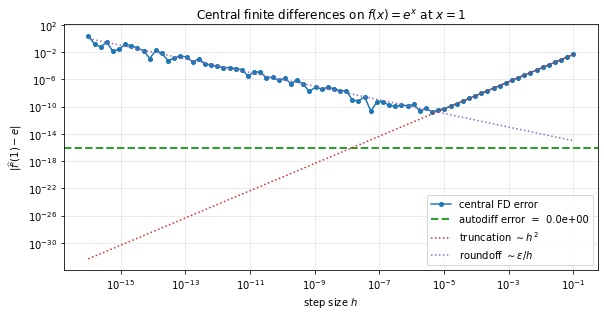

Best FD error     : 1.671e-11   at h = 4.29e-06
Autodiff error    : 0.000e+00


In [3]:
def fd_central(f, x, h):
    return (f(x + h) - f(x - h)) / (2.0 * h)

x0 = 1.0
truth = np.exp(x0)

hs = np.logspace(-16, -1, 80)
errors = np.array([abs(fd_central(np.exp, x0, h) - truth) for h in hs])

# Autodiff answer
x_t = tf.Variable(x0, dtype=tf.float64)
with tf.GradientTape() as tape:
    y = tf.exp(x_t)
ad_err = abs(tape.gradient(y, x_t).numpy() - truth)

fig, ax = plt.subplots(figsize=(8.5, 4.5))
ax.loglog(hs, errors, 'o-', color='tab:blue', markersize=4, label='central FD error')
ax.axhline(ad_err if ad_err > 0 else 1e-16, color='tab:green', linestyle='--', linewidth=2,
           label=f'autodiff error  =  {ad_err:.1e}')
# Theoretical asymptotics
ax.loglog(hs, hs**2 * np.exp(x0) / 6, color='tab:red', linestyle=':', linewidth=1.5, label=r'truncation $\sim h^2$')
ax.loglog(hs, np.full_like(hs, 1e-16) / hs, color='tab:purple', linestyle=':', linewidth=1.5, label=r'roundoff $\sim \epsilon / h$')
ax.set_xlabel(r'step size $h$')
ax.set_ylabel(r'$|\widehat{f^\prime}(1) - e|$')
ax.set_title('Central finite differences on $f(x) = e^x$ at $x = 1$')
ax.grid(True, which='both', alpha=0.3)
ax.legend(loc='lower right', fontsize=10)
plt.tight_layout(); plt.show()

print(f'Best FD error     : {errors.min():.3e}   at h = {hs[np.argmin(errors)]:.2e}')
print(f'Autodiff error    : {ad_err:.3e}')


**Reading the plot.**
- The blue dots form the classic U-curve: error first falls as $h^2$ (truncation), then climbs as $\epsilon/h$ (catastrophic cancellation).
- The minimum is around $h^\star \approx \sqrt{\epsilon} \approx 10^{-5.3}$, with best-case error $\sim 10^{-11}$. We have lost ~5 digits.
- Autodiff (green) hits machine precision at *zero* $h$ tuning.

For Hessians and higher derivatives, FD loses many more digits and is essentially unusable for moderate-precision work.

## 3. CRRA utility: $u(c) = c^{1-\gamma} / (1-\gamma)$

The standard isoelastic (CRRA) utility:
$$u(c) = \frac{c^{1-\gamma}}{1-\gamma}, \qquad u'(c) = c^{-\gamma}, \qquad u''(c) = -\gamma\, c^{-\gamma-1}.$$

We compute *both* derivatives via a single nested `GradientTape`, plot $u$, $u'$, $u''$ together, and confirm they match the closed-form expressions.

max |u'(c) AD - analytical| =  0.000e+00
max |u''(c) AD - analytical| = 0.000e+00


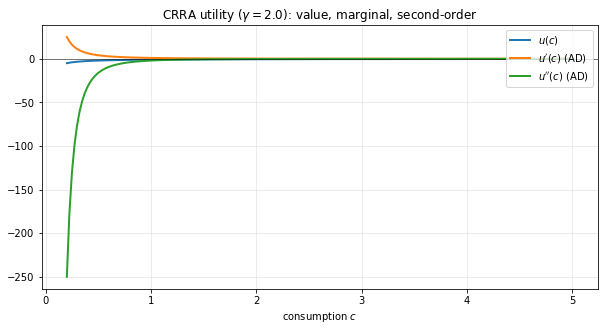

In [4]:
gamma = 2.0

def u(c):                    # the only thing we write
    return c**(1.0 - gamma) / (1.0 - gamma)

c_grid = np.linspace(0.2, 5.0, 200, dtype=np.float64)

u_vals, up_vals, upp_vals = [], [], []
for c_np in c_grid:
    c = tf.Variable(c_np, dtype=tf.float64)
    with tf.GradientTape() as t2:
        with tf.GradientTape() as t1:
            y = u(c)
        up = t1.gradient(y, c)            # first derivative via AD
    upp = t2.gradient(up, c)              # second derivative via AD
    u_vals.append(y.numpy()); up_vals.append(up.numpy()); upp_vals.append(upp.numpy())

u_vals  = np.asarray(u_vals)
up_vals = np.asarray(up_vals)
upp_vals = np.asarray(upp_vals)

# Closed-form for cross-check
up_ana  = c_grid**(-gamma)
upp_ana = -gamma * c_grid**(-gamma - 1)

print(f"max |u'(c) AD - analytical| =  {np.max(np.abs(up_vals - up_ana)):.3e}")
print(f"max |u''(c) AD - analytical| = {np.max(np.abs(upp_vals - upp_ana)):.3e}")

fig, ax = plt.subplots(figsize=(8.5, 4.7))
ax.plot(c_grid, u_vals,   label=r'$u(c)$',          linewidth=2)
ax.plot(c_grid, up_vals,  label=r"$u'(c)$ (AD)",    linewidth=2)
ax.plot(c_grid, upp_vals, label=r"$u''(c)$ (AD)",   linewidth=2)
ax.axhline(0, color='k', linewidth=0.5)
ax.set_xlabel(r'consumption $c$')
ax.set_title(rf'CRRA utility ($\gamma = {gamma}$): value, marginal, second-order')
ax.grid(True, alpha=0.3); ax.legend(loc='upper right'); plt.tight_layout(); plt.show()


**Take-away.** Change `gamma` to `4.0` -- the code does not move. The autodiff answer follows automatically. The same cell can produce the marginal utility for *any* utility function we plug into `u`.

## 4. Cobb-Douglas production: a genuinely 2D example

$$f(K, L) = K^{\alpha} L^{1-\alpha}, \qquad
f_K = \alpha K^{\alpha - 1} L^{1-\alpha}, \qquad
f_L = (1-\alpha) K^{\alpha} L^{-\alpha}.$$

We will:
1. Compute $f$ on a 2D grid in $(K, L)$.
2. Use *one* `GradientTape` to compute both partials at every grid point.
3. Visualise the surface and overlay the gradient field as a `quiver` plot.
4. Cross-check against the closed-form expressions.

In [5]:
alpha = 0.36

def f(K, L):
    return K**alpha * L**(1.0 - alpha)

# 2D grid
K_grid = np.linspace(0.5, 5.0, 25)
L_grid = np.linspace(0.5, 5.0, 25)
KK, LL = np.meshgrid(K_grid, L_grid)

# Vectorised AD on the whole grid in one go
K_t = tf.Variable(KK, dtype=tf.float64)
L_t = tf.Variable(LL, dtype=tf.float64)

with tf.GradientTape() as tape:
    Y = f(K_t, L_t)
dY = tape.gradient(Y, [K_t, L_t])
fK_ad = dY[0].numpy()
fL_ad = dY[1].numpy()

# Closed form
fK_an = alpha * KK**(alpha - 1) * LL**(1 - alpha)
fL_an = (1 - alpha) * KK**alpha * LL**(-alpha)

print(f'max |f_K (AD) - analytical| = {np.max(np.abs(fK_ad - fK_an)):.3e}')
print(f'max |f_L (AD) - analytical| = {np.max(np.abs(fL_ad - fL_an)):.3e}')


max |f_K (AD) - analytical| = 4.441e-16
max |f_L (AD) - analytical| = 1.110e-16


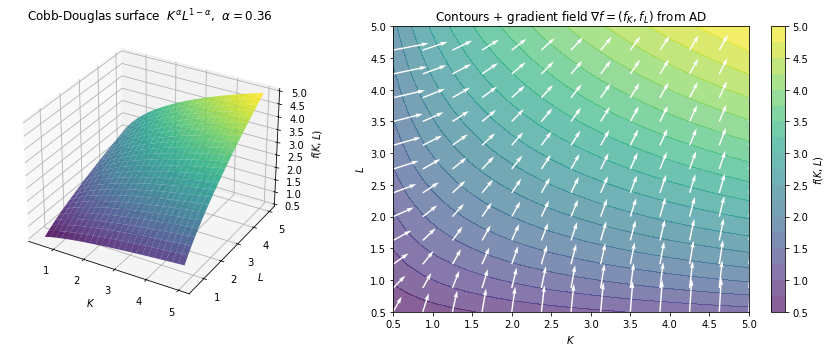

In [6]:
fig = plt.figure(figsize=(13, 5))

# Surface
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax1.plot_surface(KK, LL, Y.numpy(), cmap='viridis', alpha=0.85, edgecolor='none')
ax1.set_xlabel(r'$K$'); ax1.set_ylabel(r'$L$'); ax1.set_zlabel(r'$f(K,L)$')
ax1.set_title(r'Cobb-Douglas surface  $K^{\alpha} L^{1-\alpha}$,  $\alpha=0.36$')

# Contour + gradient field via AD
ax2 = fig.add_subplot(1, 2, 2)
cs = ax2.contourf(KK, LL, Y.numpy(), levels=18, cmap='viridis', alpha=0.65)
plt.colorbar(cs, ax=ax2, label=r'$f(K,L)$')
# Subsample for quiver
step = 2
ax2.quiver(KK[::step,::step], LL[::step,::step],
           fK_ad[::step,::step], fL_ad[::step,::step],
           color='white', scale=15, width=0.004)
ax2.set_xlabel(r'$K$'); ax2.set_ylabel(r'$L$')
ax2.set_title(r'Contours + gradient field $\nabla f = (f_K, f_L)$ from AD')
plt.tight_layout(); plt.show()


**Two things this slide makes vivid.**
1. Each white arrow is a gradient computed by autodiff at that grid point. It points in the direction of steepest increase of $f$.
2. The arrows are larger near the axes (where one input is scarce, marginal product of the other is small but the imbalanced one is large) and smaller in the middle (decreasing returns). All of that *behaviour* falls out of one `tape.gradient` call; we never wrote a partial derivative.

## 5. Capital adjustment cost: hand vs autodiff

The convex adjustment cost from the Day 3 IRBC model:
$$\Gamma(K, K') = \frac{\kappa}{2}\, K \left(\frac{K'}{K} - 1\right)^2.$$

By hand:
$$\frac{\partial \Gamma}{\partial K'} = \kappa \left(\frac{K'}{K} - 1\right), \qquad
\frac{\partial \Gamma}{\partial K} = \frac{\kappa}{2}\left(\frac{K'}{K} - 1\right)^2
- \kappa\,\frac{K'}{K}\left(\frac{K'}{K} - 1\right).$$

The first one is fine. The second needs the quotient and chain rules and is exactly the kind of expression where typos hide. Autodiff: one line.

In [7]:
kappa = 0.3

def Gamma(K, Kp):                                         # only thing the user writes
    return 0.5 * kappa * K * (Kp / K - 1.0)**2

# 2D grid
K_grid  = np.linspace(0.5, 5.0, 30)
Kp_grid = np.linspace(0.5, 5.0, 30)
KK, KKp = np.meshgrid(K_grid, Kp_grid)

K_t  = tf.Variable(KK,  dtype=tf.float64)
Kp_t = tf.Variable(KKp, dtype=tf.float64)

with tf.GradientTape() as tape:
    G = Gamma(K_t, Kp_t)
dG = tape.gradient(G, [K_t, Kp_t])
dG_dK_ad  = dG[0].numpy()
dG_dKp_ad = dG[1].numpy()

# Hand-derived
ratio = KKp / KK
dG_dKp_an = kappa * (ratio - 1.0)
dG_dK_an  = 0.5 * kappa * (ratio - 1.0)**2 - kappa * ratio * (ratio - 1.0)

print(f"max | d Gamma/d K' (AD) - hand | = {np.max(np.abs(dG_dKp_ad - dG_dKp_an)):.3e}")
print(f"max | d Gamma/d K  (AD) - hand | = {np.max(np.abs(dG_dK_ad  - dG_dK_an )):.3e}")


max | d Gamma/d K' (AD) - hand | = 2.220e-16
max | d Gamma/d K  (AD) - hand | = 3.553e-15


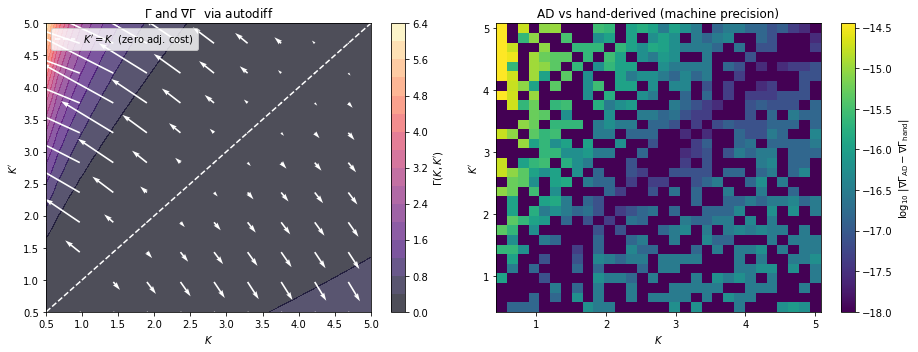

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: contour of Gamma + gradient quiver from AD
cs = axes[0].contourf(KK, KKp, G.numpy(), levels=18, cmap='magma', alpha=0.7)
plt.colorbar(cs, ax=axes[0], label=r'$\Gamma(K, K^\prime)$')
step = 3
axes[0].quiver(KK[::step,::step], KKp[::step,::step],
               dG_dK_ad[::step,::step], dG_dKp_ad[::step,::step],
               color='white', scale=4, width=0.005)
axes[0].plot(K_grid, K_grid, 'w--', linewidth=1.5, label=r'$K^\prime = K$  (zero adj. cost)')
axes[0].set_xlabel(r'$K$'); axes[0].set_ylabel(r'$K^\prime$')
axes[0].set_title(r'$\Gamma$ and $\nabla \Gamma$  via autodiff')
axes[0].legend(loc='upper left')

# Right: AD vs hand (cross-check)
err_K  = np.abs(dG_dK_ad  - dG_dK_an)
err_Kp = np.abs(dG_dKp_ad - dG_dKp_an)
im = axes[1].pcolormesh(KK, KKp, np.log10(err_K + err_Kp + 1e-18), shading='auto', cmap='viridis')
plt.colorbar(im, ax=axes[1], label=r'$\log_{10}\,|\nabla \Gamma_{\rm AD} - \nabla \Gamma_{\rm hand}|$')
axes[1].set_xlabel(r'$K$'); axes[1].set_ylabel(r'$K^\prime$')
axes[1].set_title('AD vs hand-derived (machine precision)')
plt.tight_layout(); plt.show()


**What the gradient field shows.**
- On the diagonal $K' = K$, the cost is zero and $\nabla \Gamma = 0$.
- Off the diagonal, the gradient points back towards the diagonal (smoothly): the planner pays a quadratic penalty for deviating from no adjustment.

**What the cross-check shows.** AD agrees with the hand-derived expression to ~$10^{-15}$ across the grid. We did *not* have to differentiate by hand to know this is correct; we just ran both and looked at the difference.

## 6. Bonus: the Hessian via nested `GradientTape`

The Hessian of Cobb-Douglas at a point $(K, L)$ has three independent entries:
$$H = \begin{pmatrix} f_{KK} & f_{KL} \\ f_{KL} & f_{LL} \end{pmatrix}.$$

We get the whole matrix by nesting two tapes.

In [9]:
K = tf.Variable(3.0, dtype=tf.float64)
L = tf.Variable(2.0, dtype=tf.float64)

with tf.GradientTape() as outer:
    with tf.GradientTape() as inner:
        Y = f(K, L)
    grads = inner.gradient(Y, [K, L])
fK, fL = grads
# Now differentiate each gradient again
H_K = outer.gradient(fK, [K, L])
# Re-tape for second row (Tape is consumed)
with tf.GradientTape() as outer2:
    with tf.GradientTape() as inner2:
        Y = f(K, L)
    grads2 = inner2.gradient(Y, [K, L])
H_L = outer2.gradient(grads2[1], [K, L])

H_ad = np.array([[H_K[0].numpy(), H_K[1].numpy()],
                 [H_L[0].numpy(), H_L[1].numpy()]])

# Hand-derived Hessian
fKK = alpha * (alpha - 1) * K.numpy()**(alpha - 2) * L.numpy()**(1 - alpha)
fLL = (1 - alpha) * (-alpha) * K.numpy()**alpha * L.numpy()**(-alpha - 1)
fKL = alpha * (1 - alpha) * K.numpy()**(alpha - 1) * L.numpy()**(-alpha)
H_an = np.array([[fKK, fKL],
                 [fKL, fLL]])

print('AD Hessian:'); print(H_ad)
print('\nHand Hessian:'); print(H_an)
print(f'\nmax abs diff: {np.max(np.abs(H_ad - H_an)):.3e}')


AD Hessian:
[[-0.05924652  0.08886977]
 [ 0.08886977 -0.13330466]]

Hand Hessian:
[[-0.05924652  0.08886977]
 [ 0.08886977 -0.13330466]]

max abs diff: 1.388e-17


Three things to notice:
- The Hessian is symmetric -- both AD and the hand formula recover this exactly. (AD does *not* assume symmetry; it gets it because it correctly computes second derivatives.)
- A single nested-tape pattern generalises to *any* Hessian. Trying this with finite differences would lose roughly 10 digits of precision; here we lose zero.
- The same idea, applied to a neural network's loss, is what produces curvature information for second-order optimisers (K-FAC, Newton-CG, etc.).

## 7. Summary

You have just used `tf.GradientTape` to:
- compute first and second derivatives of one-variable functions (warm-up, CRRA),
- compute gradient *fields* on 2D grids (Cobb-Douglas, capital adjustment cost),
- regenerate the textbook FD U-curve and confirm autodiff sits at machine precision,
- assemble a full Hessian via two nested tapes.

In every example the user writes only the **model primitive** -- the utility function, the production function, the cost function. All derivatives are computed by autodiff, exactly to machine precision, with no hand algebra and no finite-difference step-size tuning.

### Where to go next

The same pattern -- write only the *period payoff* $\Pi(K_t, K_{t+1}, z_t)$, then call `tape.gradient` -- is what powers the Brock-Mirman DEQN solvers in:

- `02_Brock_Mirman_AutoDiff_DEQN.ipynb` -- deterministic case; cross-checks against the analytical $K_{t+1} = \alpha\beta K_t^\alpha$.
- `03_Brock_Mirman_Uncertainty_AutoDiff_DEQN.ipynb` -- AR(1) productivity with Gauss-Hermite; cross-checks against the closed-form $K_{t+1} = \alpha\beta z_t K_t^\alpha$ in the full-depreciation side-experiment.

Both notebooks include numerical cross-checks of the autodiff loss against the hand-derived Euler residual at machine precision (~$10^{-6}$ in float32).